# **Proyek Analisis Data: Bike Sharing Dataset**
- **Nama:** Fara Katty Sabila
- **Email:** farakettyy354@gmail.com
- **ID Dicoding:** avavictorry

## **Menentukan Pertanyaan Bisnis**

1. Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah peminjaman sepeda harian?
2. Pada jam berapa saja terjadi puncak peminjaman sepeda, dan bagaimana polanya antara hari kerja vs hari libur?

## **Import Semua Packages/Library yang Digunakan**

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setting style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120



## **Data Wrangling**

### **Gathering Data**

In [107]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

print("Shape day_df:", day_df.shape)
print("Shape hour_df:", hour_df.shape)

day_df.head()

Shape day_df: (731, 16)
Shape hour_df: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [108]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset `day.csv` berisi data agregat harian peminjaman sepeda dengan 731 baris dan 16 kolom.
- Datase `hour.cs`' berisi data per jam dengan 17.379 baris dan 17 kolom yang mencakup variabel tambahan `hr` (jam) dibanding dataset harian.
- Kedua dataset memiliki kolom yang hampir identik dengan `hour.csv`  sebagai data granular yang lebih detail.

### **Assessing Data**

#### Info Dataset

In [109]:
print("== Info day_df ==\n")
day_df.info()

== Info day_df ==

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [110]:
print("== Info hour_df ==\n")
hour_df.info()

== Info hour_df ==

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Missing Values

In [111]:
print("== Missing values day_df ==")
day_df.isna().sum()

== Missing values day_df ==


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [112]:
print("== Missing values hour_df ==")
hour_df.isna().sum()

== Missing values hour_df ==


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Duplikat Data

In [113]:
print("== Duplikat day_df ==")
day_df.duplicated().sum()

== Duplikat day_df ==


np.int64(0)

In [114]:
print("== Duplikat hour_df ==")
hour_df.duplicated().sum()

== Duplikat hour_df ==


np.int64(0)

#### Statistik Deskriptif

In [115]:
print("== Statistik Deskriptif day_df ==")
day_df.describe()

== Statistik Deskriptif day_df ==


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [116]:
print("== Statistik Deskriptif hour_df ==")
hour_df.describe()

== Statistik Deskriptif hour_df ==


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### Tipe Data & Nilai Unik Kolom Kategorikal

In [117]:
# 1. day_df
categorical_cols = ['season', 'yr', 'mnth', 'weekday', 'workingday', 'weathersit']
day_unique = []
for col in categorical_cols:
    day_unique.append({
        "Dataset": "day_df",
        "Kolom": col,
        "Jumlah Unik": day_df[col].nunique(),
        "Nilai Unik": sorted(day_df[col].unique()),
    })

# 2. hour_df
hr_unique = [{
    "Dataset": "hour_df",
    "Kolom": "hr",
    "Jumlah Unik": hour_df['hr'].nunique(),
    "Nilai Unik": sorted(hour_df['hr'].unique().tolist())
}]

summary_df = pd.concat([pd.DataFrame(day_unique), pd.DataFrame(hr_unique)], ignore_index=True)

summary_df

,Dataset,Kolom,Jumlah Unik,Nilai Unik
0,day_df,season,4,"[1, 2, 3, 4]"
1,day_df,yr,2,"[0, 1]"
2,day_df,mnth,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,day_df,weekday,7,"[0, 1, 2, 3, 4, 5, 6]"
4,day_df,workingday,2,"[0, 1]"
5,day_df,weathersit,3,"[1, 2, 3]"
6,hour_df,hr,24,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


**Insight:**
-  Tidak ditemukan missing values maupun duplikat pada kedua dataset.
- Kolom `dteday` masih bertipe `object` (string), perlu dikonversi ke tipe `datetime`.
- Kolom kategorikal seperti `season`, `mnth`, `weekday`, dan `weathersit` masih bertipe `int64`, perlu dikonversi ke tipe yang lebih deskriptif agar mudah dibaca saat visualisasi.
- Nilai `temp`, `atemp`, `hum`, dan `windspeed` dalam bentuk normalisasi (0–1), perlu diperhatikan saat interpretasi.

### **Cleaning Data**

Berdasarkan hasil assessing, terdapat dua hal yang perlu dibersihkan:
1. Kolom `dteday` perlu dikonversi dari `object` ke `datetime`
2. Kolom kategorikal perlu dikonversi dari `int64` ke label yang lebih deskriptif

#### Konversi datetime

In [118]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("Tipe dteday day_df :", day_df['dteday'].dtype)
print("Tipe dteday hour_df :", hour_df['dteday'].dtype)

Tipe dteday day_df : datetime64[ns]
Tipe dteday hour_df : datetime64[ns]


#### Konversi label kategorikal

In [119]:
# Mapping label
season_map      = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
month_map       = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
                  7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
weekday_map     = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri',6: 'Sat'}
weather_map     = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
yr_map          = {0: '2011', 1: '2012'}
holiday_map     = {0: 'No', 1: 'Yes'}
workingday_map  = {0: 'No', 1: 'Yes'}

# Apply ke day_df
day_df['season']     = day_df['season'].map(season_map)
day_df['mnth']       = day_df['mnth'].map(month_map)
day_df['weekday']    = day_df['weekday'].map(weekday_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)
day_df['yr']         = day_df['yr'].map(yr_map)
day_df['holiday']    = day_df['holiday'].map(holiday_map)
day_df['workingday'] = day_df['workingday'].map(workingday_map)

# Apply ke hour_df
hour_df['season']     = hour_df['season'].map(season_map)
hour_df['mnth']       = hour_df['mnth'].map(month_map)
hour_df['weekday']    = hour_df['weekday'].map(weekday_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)
hour_df['yr']         = hour_df['yr'].map(yr_map)
hour_df['holiday']    = hour_df['holiday'].map(holiday_map)
hour_df['workingday'] = hour_df['workingday'].map(workingday_map)

print("Cleaning done")
day_df.head()

Cleaning done


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,No,Sat,No,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Jan,No,Sun,No,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Jan,No,Mon,Yes,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,Jan,No,Tue,Yes,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,Jan,No,Wed,Yes,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [120]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,No,Sat,No,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,Jan,1,No,Sat,No,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,Jan,2,No,Sat,No,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,Jan,3,No,Sat,No,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,Jan,4,No,Sat,No,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [121]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    object        
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    object        
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime` pada kedua dataset.
- Seluruh kolom kategorikal berhasil dikonversi dari kode angka menjadi label deskriptif (misal: `1` → `'Spring'`, `1` → `'Clear'`) sehingga lebih mudah dibaca saat visualisasi.
- Tidak ada penghapusan baris karena tidak ditemukan missing values maupun duplikat pada tahap assessing.

## **Exploratory Data Analysis (EDA)**

### **1. Explore Pengaruh Musim dan Cuaca terhadap Peminjaman Sepeda Harian (day_df)**

In [122]:
# Rata-rata peminjaman per musim
season_stats = day_df.groupby('season')['cnt'].agg(['mean', 'median', 'std']).reset_index()
season_stats.columns = ['Season', 'Mean', ' Median', 'Std']
season_stats = season_stats.sort_values('Mean', ascending=False)
print("Rata-rata peminjaman per musim:")
season_stats

Rata-rata peminjaman per musim:


,Season,Mean,Median,Std
0,Fall,5644.303191,5353.5,1459.800381
2,Summer,4992.331522,4941.5,1695.977235
3,Winter,4728.162921,4634.5,1699.615261
1,Spring,2604.132597,2209.0,1399.942119


In [123]:
# Rata-rata peminjaman per kondisi cuaca
weather_stats = day_df.groupby('weathersit')['cnt'].agg(['mean', 'median', 'std']).reset_index()
weather_stats.columns = ['Weather', 'Mean', 'Median', 'Std']
weather_stats = weather_stats.sort_values('Mean', ascending=False)
print("Rata-rata peminjaman per cuaca:")
weather_stats

Rata-rata peminjaman per cuaca:


,Weather,Mean,Median,Std
0,Clear,4876.786177,4844.0,1879.483989
2,Mist,4035.862348,4040.0,1809.109918
1,Light Snow/Rain,1803.285714,1817.0,1240.284449


In [124]:
# Korelasi variabel numerik thd cnt
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr_matrix = day_df[numeric_cols].corr()
print("Korelasi terhadap cnt:")
corr_matrix[['cnt']].sort_values('cnt', ascending=False)

Korelasi terhadap cnt:


,cnt
cnt,1.000000
atemp,0.631066
temp,0.627494
hum,-0.100659
windspeed,-0.234545


**Insight:**
- Musim **Fall** memiliki rata-rata peminjaman tertinggi, diikuti **Summer** dan **Winter**, sedangkan **Spring** terendah.
- Kondisi cuaca **Clear** menghasilkan peminjaman tertinggi. Semakin buruk cuaca, semakin sedikit peminjaman.
- Variabel `temp` dan `atemp` memiliki korelasi positif tertinggi terhadap `cnt`, artinya suhu yang lebih hangat cenderung meningkatkan peminjaman.
- `hum` dan `windspeed` berkorelasi negatif terhadap `cnt`.

### **2. Explore Pola Peminjaman Per Jam (hour_df)**

In [125]:
# Rata-rata peminjaman per jam
hourly_stats = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly_stats.columns = ['Hour', 'Mean']
print("Rata-rata peminjaman per jam:")
hourly_stats

Rata-rata peminjaman per jam:


,Hour,Mean
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


In [126]:
# Rata-rata peminjaman per jam berdasarkan hari kerja vs libur
hourly_workday = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
hourly_workday.columns = ['Hour', 'Workingday', 'Mean']

# Tampilkan dalam format wide agar mudah dibaca
hourly_pivot = hourly_workday.pivot(index='Hour', columns='Workingday', values='Mean')
hourly_pivot.columns = ['Non-Workingday', 'Workingday']
hourly_pivot.columns.name = None
hourly_pivot

,Non-Workingday,Workingday
Hour,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048


In [127]:
# Jam puncak hari kerja
peak_workday = hourly_workday[hourly_workday['Workingday'] == 'Yes'].nlargest(5, 'Mean')
print("Top 5 jam puncak - Hari Kerja:")
print(peak_workday.to_string(index=False))

# Jam puncak hari libur
peak_holiday = hourly_workday[hourly_workday['Workingday'] == 'No'].nlargest(5, 'Mean')
print("\nTop 5 jam puncak - Hari Libur")
print(peak_holiday.to_string(index=False))


Top 5 jam puncak - Hari Kerja:
 Hour Workingday       Mean
   17        Yes 525.290581
   18        Yes 492.226908
    8        Yes 477.006048
   19        Yes 348.401606
   16        Yes 293.122244

Top 5 jam puncak - Hari Libur
 Hour Workingday       Mean
   13         No 372.731602
   12         No 366.259740
   14         No 364.645022
   15         No 358.813853
   16         No 352.727273


**Insight:**
- Pada **hari kerja**, terdapat dua puncak peminjaman yang jelas:
  - Jam **08.00** (rata-rata 477 peminjaman) → waktu berangkat kerja
  - Jam **17.00–18.00** (rata-rata 525 & 492 peminjaman) → waktu pulang kerja
  - Pola ini disebut **bimodal** karena ada dua puncak dalam sehari
- Pada **hari libur (Non-Workingday)**, pola peminjaman lebih landai dengan puncak tunggal di siang hari:
  - Jam **12.00–15.00** (rata-rata 352–373 peminjaman) → pola rekreasi/santai
- Jam **00.00–05.00** konsisten menjadi periode peminjaman terendah di semua hari, dengan rata-rata di bawah 55 peminjaman.
- Rata-rata peminjaman per jam tertinggi secara keseluruhan terjadi pada jam **17.00** (461 peminjaman), yang merupakan jam pulang kerja.

## **Visualization & Explanatory Analysis**

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah peminjaman sepeda harian?

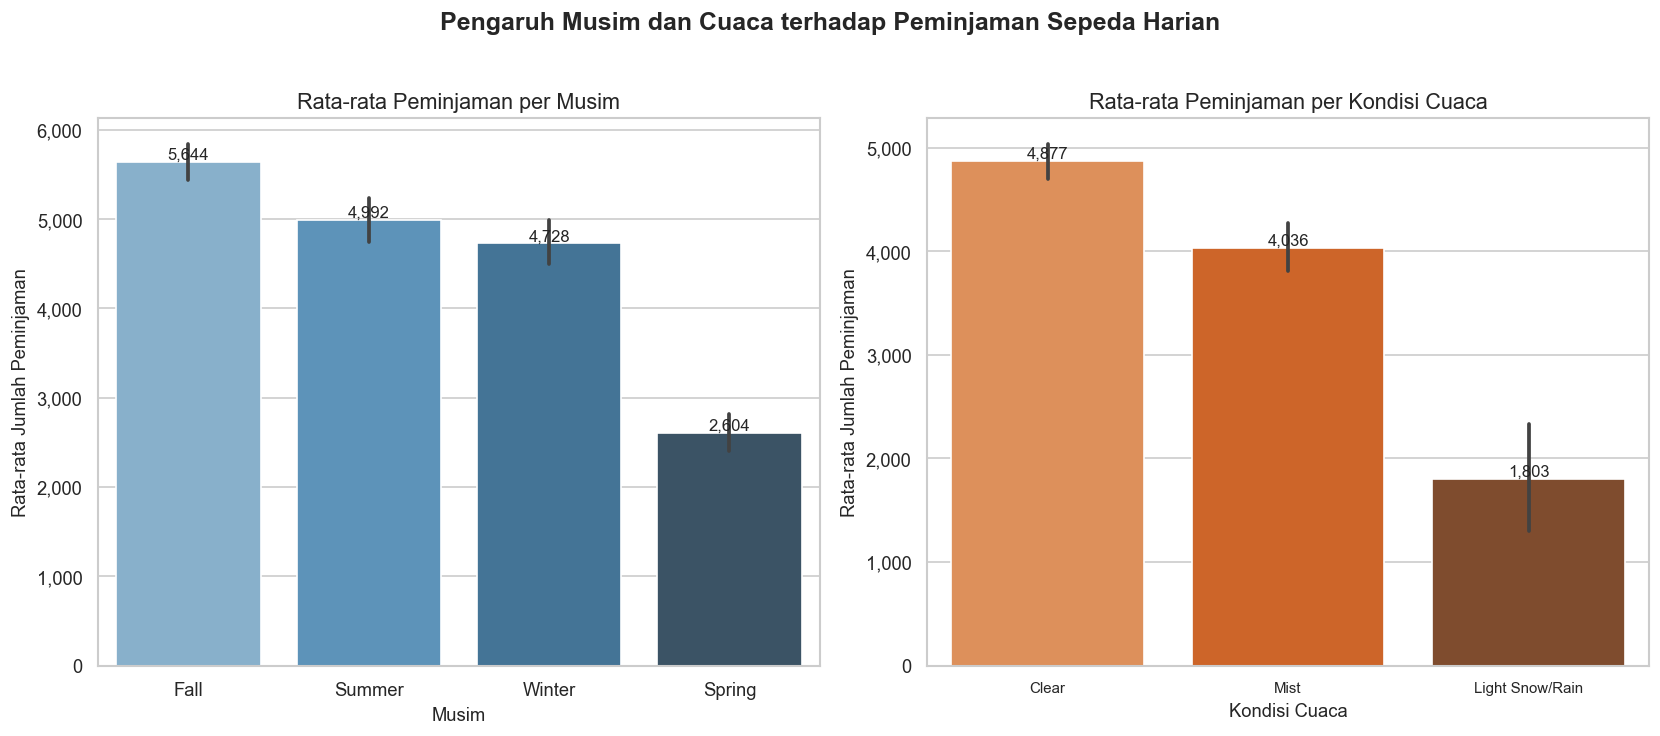

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pengaruh Musim dan Cuaca terhadap Peminjaman Sepeda Harian', 
             fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Rata-rata peminjaman per musim
season_order = day_df.groupby('season')['cnt'].mean().sort_values(ascending=False).index

sns.barplot(
    data=day_df,
    x='season', y='cnt',
    order=season_order,
    palette='Blues_d',
    ax=axes[0]
)
axes[0].set_title('Rata-rata Peminjaman per Musim', fontsize=13)
axes[0].set_xlabel('Musim', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[0].yaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Tambah label nilai di atas bar
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Plot 2: Rata-rata peminjaman per kondisi cuaca 
weather_order = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False).index

sns.barplot(
    data=day_df,
    x='weathersit', y='cnt',
    order=weather_order,
    palette='Oranges_d',
    ax=axes[1]
)
axes[1].set_title('Rata-rata Peminjaman per Kondisi Cuaca', fontsize=13)
axes[1].set_xlabel('Kondisi Cuaca', fontsize=11)
axes[1].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[1].yaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', labelsize=9)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('visualization_q1.png', bbox_inches='tight')
plt.show()

**Insight:**
- Musim **Fall** mencatat rata-rata peminjaman tertinggi (~5.644), diikuti **Summer** (~4.992),
  **Winter** (~4.728), dan terendah **Spring** (~2.604). Perbedaan Spring vs Fall hampir 2x lipat,
  menunjukkan musim berpengaruh besar terhadap minat bersepeda.
- Kondisi cuaca **Clear** menghasilkan rata-rata tertinggi (~4.877), diikuti **Mist** (~4.036),
  dan **Light Snow/Rain** terendah (~1.803). Penurunan dari Clear ke Light Snow/Rain mencapai ~63%.
- Tidak ada data **Heavy Rain** (weathersit=4) dalam dataset harian, artinya kondisi ekstrem
  sangat jarang terjadi.
- Secara keseluruhan, **musim dan cuaca berpengaruh signifikan** terhadap jumlah peminjaman harian —
  semakin hangat dan cerah, semakin tinggi peminjaman.

### Pertanyaan 2: Pada jam berapa saja terjadi puncak peminjaman sepeda, dan bagaimana polanya antara hari kerja vs hari libur?

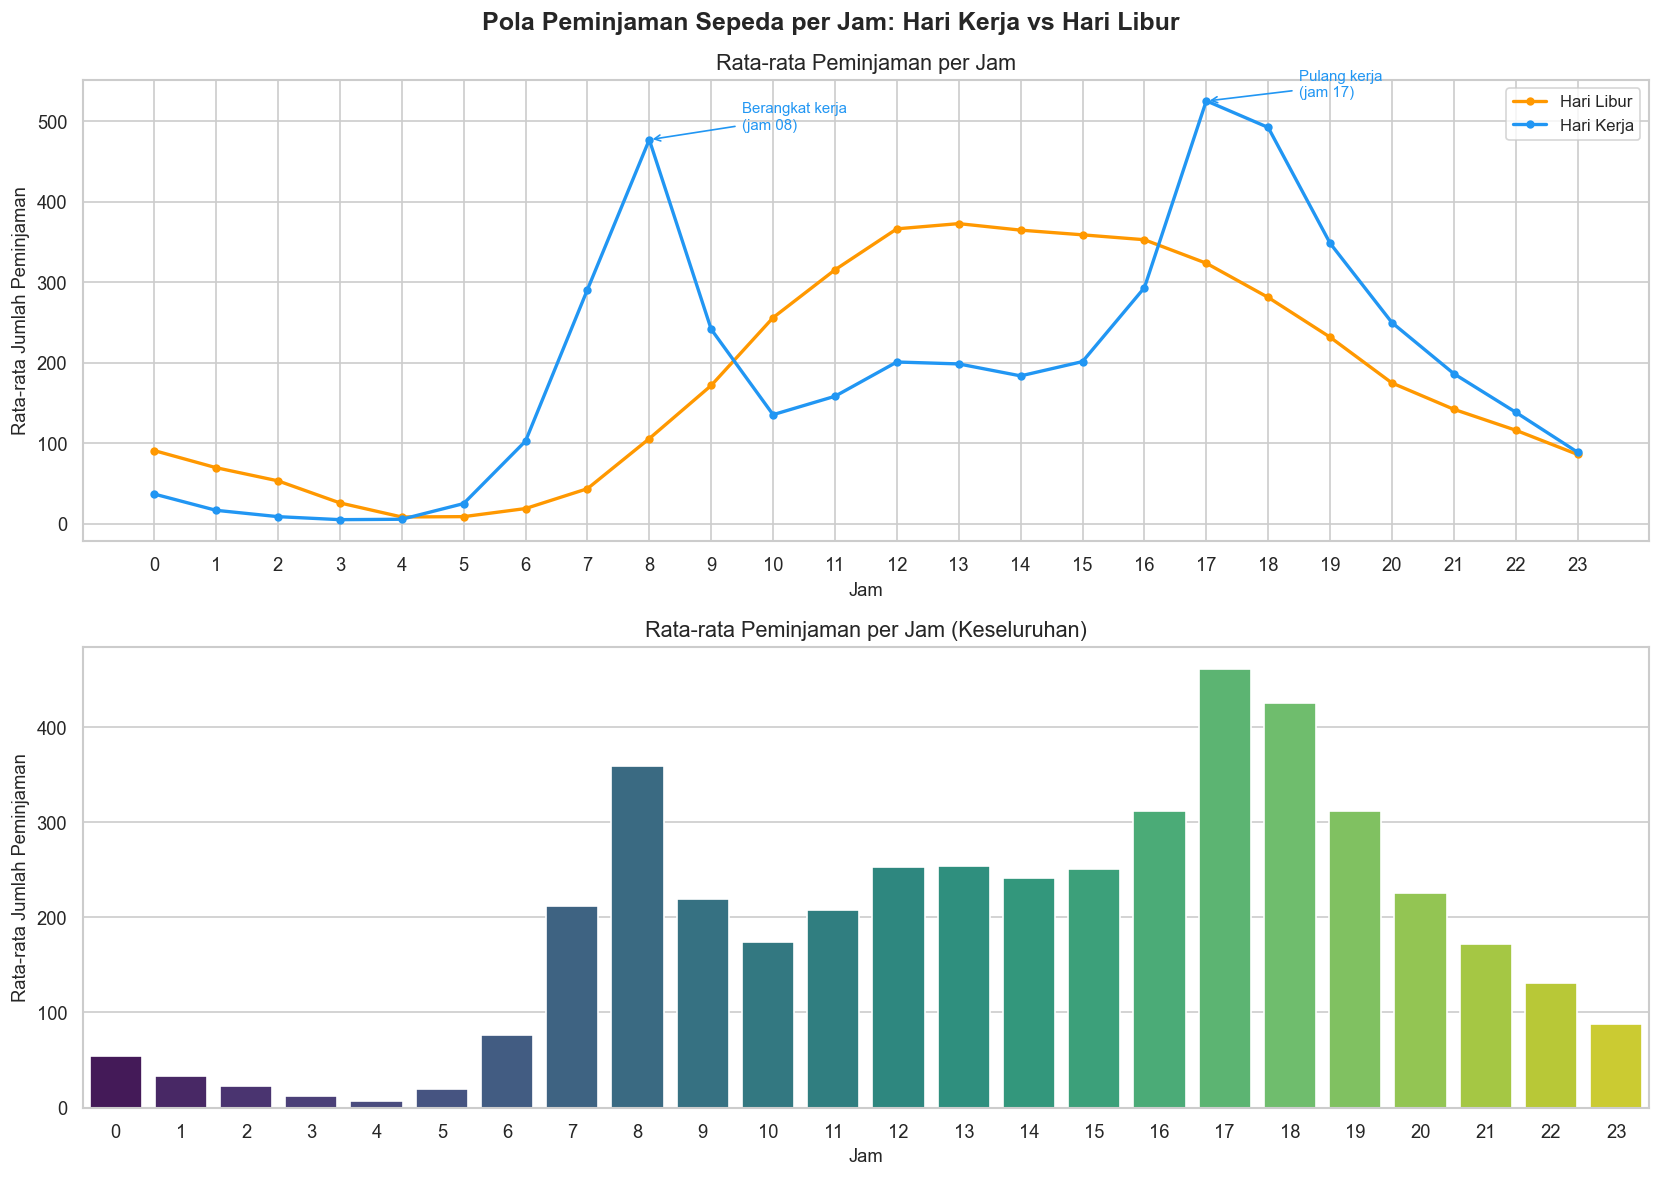

In [129]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Pola Peminjaman Sepeda per Jam: Hari Kerja vs Hari Libur',
             fontsize=15, fontweight='bold')

# Plot 1: Line chart per jam (workingday vs non-workingday) 
colors = {'Yes': '#2196F3', 'No': '#FF9800'}

for workingday, group in hourly_workday.groupby('Workingday'):
    label = 'Hari Kerja' if workingday == 'Yes' else 'Hari Libur'
    axes[0].plot(group['Hour'], group['Mean'], 
                 marker='o', markersize=4,
                 label=label, color=colors[workingday], linewidth=2)

axes[0].set_title('Rata-rata Peminjaman per Jam', fontsize=13)
axes[0].set_xlabel('Jam', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anotasi puncak hari kerja
axes[0].annotate('Berangkat kerja\n(jam 08)', xy=(8, 477), xytext=(9.5, 490),
                 fontsize=9, color='#2196F3',
                 arrowprops=dict(arrowstyle='->', color='#2196F3'))
axes[0].annotate('Pulang kerja\n(jam 17)', xy=(17, 525), xytext=(18.5, 530),
                 fontsize=9, color='#2196F3',
                 arrowprops=dict(arrowstyle='->', color='#2196F3'))

# Plot 2: Bar chart total peminjaman per jam (keseluruhan) 
sns.barplot(
    data=hourly_stats,
    x='Hour', y='Mean',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Rata-rata Peminjaman per Jam (Keseluruhan)', fontsize=13)
axes[1].set_xlabel('Jam', fontsize=11)
axes[1].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[1].yaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('visualization_q2.png', bbox_inches='tight')
plt.show()

**Insight:**
- Pada **hari kerja**, pola peminjaman bersifat **bimodal** dengan dua puncak jelas:
  - Jam **08.00** (~477 peminjaman) → waktu berangkat kerja
  - Jam **17.00–18.00** (~525 & 492 peminjaman) → waktu pulang kerja
- Pada **hari libur**, pola lebih landai dengan puncak tunggal di jam **12.00–15.00** (~352–373 peminjaman) yang mencerminkan aktivitas rekreasi.
- Jam **00.00–05.00** adalah periode paling sepi dengan rata-rata di bawah 55 peminjaman per jam.

## **Analisis Lanjutan**

### Clustering dengan Binning: Segmentasi Jam Berdasarkan Volume Peminjaman

Analisis ini bertujuan mengelompokkan jam dalam sehari ke dalam beberapa kategori waktu 
berdasarkan rata-rata volume peminjaman sepeda. Teknik yang digunakan adalah **binning** — 
membagi data ke dalam interval tertentu berdasarkan aturan domain (pemahaman pola aktivitas manusia).

Kategori waktu yang digunakan:
- **Dini Hari**: jam 00.00-05.00
- **Pagi**: jam 06.00–09.00
- **Siang**: jam 10.00–14.00
- **Sore**: jam 15.00–18.00
- **Malam**: jam 19.00–23.00

In [130]:
def categorize_hour(hr):
    if 0 <= hr <= 5:
        return 'Dini Hari'
    elif 6 <= hr <= 9:
        return 'Pagi'
    elif 10 <= hr <= 14:
        return 'Siang'
    elif 15 <= hr <= 18:
        return 'Sore'
    else:
        return 'Malam'
    
hour_df['time_category'] = hour_df['hr'].apply(categorize_hour)

# Statistik per kategori waktu
time_stats = hour_df.groupby('time_category')['cnt'].agg(['mean', 'median', 'sum']).reset_index()
time_stats.columns = ['Kategori Waktu', 'Rata-rata', 'Median', 'Total']
time_stats['Rata-rata'] = time_stats['Rata-rata'].round(2)
time_stats['Median'] = time_stats['Median'].round(2)

# Urutkan berdasarkan rata-rata tertinggi
time_order = ['Dini Hari', 'Pagi', 'Siang', 'Sore', 'Malam']
time_stats['Kategori Waktu'] = pd.Categorical(time_stats['Kategori Waktu'], categories=time_order, ordered=True)
time_stats = time_stats.sort_values('Kategori Waktu')
time_stats

,Kategori Waktu,Rata-rata,Median,Total
0,Dini Hari,24.91,13.0,106509
2,Pagi,216.70,169.0,629742
3,Siang,225.98,198.0,822562
4,Sore,362.54,327.0,1057529
1,Malam,185.81,155.0,676337


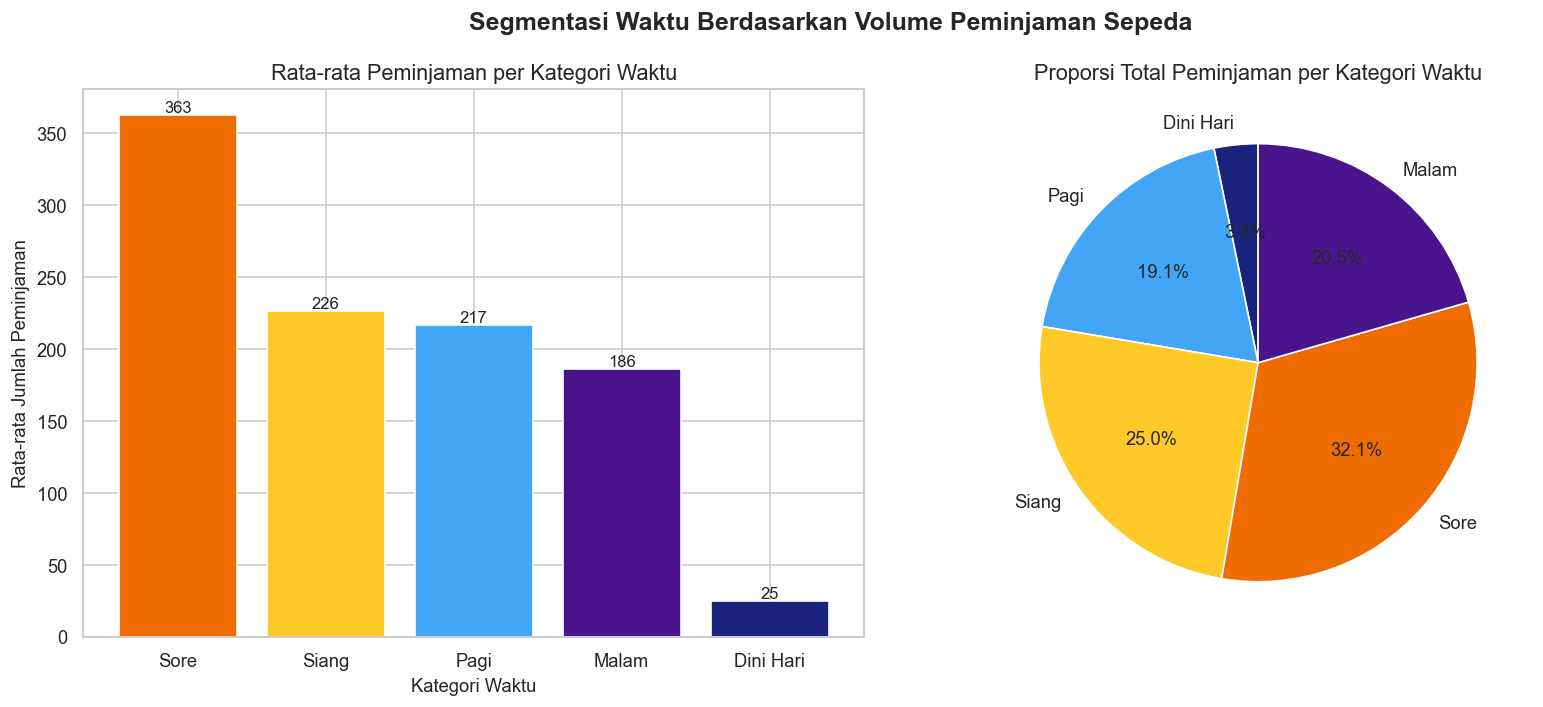

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Segmentasi Waktu Berdasarkan Volume Peminjaman Sepeda',
             fontsize=15, fontweight='bold')

palette = {
    'Dini Hari': '#1a237e',
    'Pagi'     : '#42a5f5',
    'Siang'    : '#ffca28',
    'Sore'     : '#ef6c00',
    'Malam'    : '#4a148c'
}

# Plot 1: Bar chart rata-rata per kategori waktu 
ax0_data = time_stats.sort_values('Rata-rata', ascending=False)
bars = axes[0].bar(
    ax0_data['Kategori Waktu'],
    ax0_data['Rata-rata'],
    color=[palette[k] for k in ax0_data['Kategori Waktu']]
)
axes[0].set_title('Rata-rata Peminjaman per Kategori Waktu', fontsize=13)
axes[0].set_xlabel('Kategori Waktu', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[0].yaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar in bars:
    axes[0].annotate(f'{bar.get_height():,.0f}',
                     (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Plot 2: Pie chart proporsi total peminjaman 
axes[1].pie(
    time_stats['Total'],
    labels=time_stats['Kategori Waktu'],
    colors=[palette[k] for k in time_stats['Kategori Waktu']],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi Total Peminjaman per Kategori Waktu', fontsize=13)

plt.tight_layout()
plt.savefig('visualization_clustering.png', bbox_inches='tight')
plt.show()

**Insight:**
- Kategori **Sore** (jam 15.00–18.00) mendominasi dengan rata-rata tertinggi (363 peminjaman) dan proporsi total terbesar (32.1%), didorong oleh jam pulang kerja.
- Kategori **Siang** (jam 10.00–14.00) berada di posisi kedua (226 peminjaman, 25.0%), lebih banyak dimanfaatkan saat hari libur untuk aktivitas rekreasi.
- Kategori **Pagi** (jam 06.00–09.00) di posisi ketiga (217 peminjaman, 19.1%), mencerminkan aktivitas berangkat kerja/sekolah.
- Kategori **Malam** (jam 19.00–23.00) memiliki rata-rata 186 peminjaman (20.5%), cukup signifikan kemungkinan untuk aktivitas hiburan malam hari.
- Kategori **Dini Hari** (jam 00.00–05.00) adalah periode paling sepi (25 peminjaman, 3.2%).
- Segmentasi ini dapat dimanfaatkan operator untuk **mengoptimalkan ketersediaan sepeda**, untuk bisa memprioritaskan ketersediaan stok di periode Sore dan Siang, serta mengurangi di Dini Hari.

## **Conclusion**

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah peminjaman sepeda harian?

Musim dan cuaca terbukti berpengaruh signifikan terhadap jumlah peminjaman harian. Musim **Fall** mencatat rata-rata peminjaman tertinggi (~5.644), sementara **Spring** terendah (~2.604), selisihnya hampir 2x lipat. Dari sisi cuaca, kondisi **Clear** menghasilkan peminjaman tertinggi (~4.877), sedangkan **Light Snow/Rain** turun drastis hingga ~1.803 (penurunan ~63%). Ini menunjukkan bahwa **kondisi alam adalah faktor utama** yang mempengaruhi keputusan pengguna untuk meminjam sepeda. Operator sebaiknya meningkatkan ketersediaan armada di musim Fall dan hari-hari bercerah, serta mempertimbangkan strategi promosi di musim Spring dan cuaca buruk.


### Pertanyaan 2: Pada jam berapa saja terjadi puncak peminjaman sepeda, dan bagaimana polanya antara hari kerja vs hari libur?

Terdapat perbedaan pola yang jelas antara hari kerja dan hari libur. Pada **hari kerja**, pola bersifat **bimodal** dengan dua puncak di jam **08.00** (berangkat kerja) dan jam **17.00–18.00** (pulang kerja). Pada **hari libur**, pola lebih landai dengan puncak tunggal di siang hari (jam **12.00–15.00**) yang mencerminkan aktivitas rekreasi. Dari analisis clustering, periode **Sore** (32.1%) dan **Siang** (25.0%) mendominasi total peminjaman. Operator dapat mengoptimalkan distribusi sepeda berdasarkan segmentasi waktu ini untuk memastikan stok penuh di jam sibuk pagi dan sore pada hari kerja.